In [43]:
import glob
import re
import os
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({"font.size": 10})

# -------------------------------
# Directory containing the files
# -------------------------------
in_dir = "../out"
out_dir = "../out"
os.makedirs(out_dir, exist_ok=True)

# -------------------------------
# Find and group files
# -------------------------------
files = glob.glob(os.path.join(in_dir, "*.out"))
pattern = re.compile(r"^(.*?)_mpi\d+_(.*?)\.out$")  # capture <something> and <something_else>

groups = defaultdict(list)
for f in files:
    fname = os.path.basename(f)
    m = pattern.match(fname)
    if m:
        key = (m.group(1), m.group(2))
        groups[key].append(f)

# -------------------------------
# Combine each group
# -------------------------------
for (prefix, suffix), flist in groups.items():
    flist = sorted(flist)
    out_file = os.path.join(out_dir, f"{prefix}_mpi_{suffix}.out")
    with open(out_file, "w") as fout:
        for fname in flist:
            with open(fname) as fin:
                for line in fin:
                    fout.write(line)
    print(f"Combined {len(flist)} files into {out_file}")


Combined 1 files into ../out/nfw_mpi_mg.out
Combined 2 files into ../out/nfw_mpi_fmm_2.out
Combined 2 files into ../out/nfw_mpi_fmm_1.out


In [44]:
def load_data(filename1, filename2, out_dir="../out"):
    names = ["x", "y", "z", "fx", "fy", "fz", "phi"]
    file1 = os.path.join(out_dir, filename1)
    file2 = os.path.join(out_dir, filename2)

    df1 = pd.read_csv(file1, header=None, sep=r"\s+", names=names)
    df2 = pd.read_csv(file2, header=None, sep=r"\s+", names=names)

    for df in [df1, df2]:
        df["x"] -= df["x"].min()
        df["y"] -= df["y"].min()
        df["z"] -= df["z"].min()

    return df1, df2, filename1, filename2

# ---------------------------------------------------------------------
# 2D comparison plot
# ---------------------------------------------------------------------
def plot_2d(df1, df2, label1, label2, z_slice):
    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]

    grid1 = df1_slice.pivot(index="y", columns="x", values="phi")
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi")

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    im0 = axs[0].imshow(grid1.values, origin="lower", cmap="viridis")
    axs[0].set_title(f"{label1}  (z={z_slice})")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(grid2.values, origin="lower", cmap="viridis")
    axs[1].set_title(f"{label2}  (z={z_slice})")
    plt.colorbar(im1, ax=axs[1])

    diff = grid2.values - grid1.values
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_diff = np.where(grid1.values != 0, diff / grid1.values, 0)
    im2 = axs[2].imshow(rel_diff, origin="lower", cmap="coolwarm")
    axs[2].set_title("Relative Difference")
    plt.colorbar(im2, ax=axs[2])

    plt.tight_layout()
    os.makedirs("./fig", exist_ok=True)
    plt.savefig(f"./fig/compare_2d_{z_slice}_{label1}_vs_{label2}.png", dpi=200)
    plt.show()

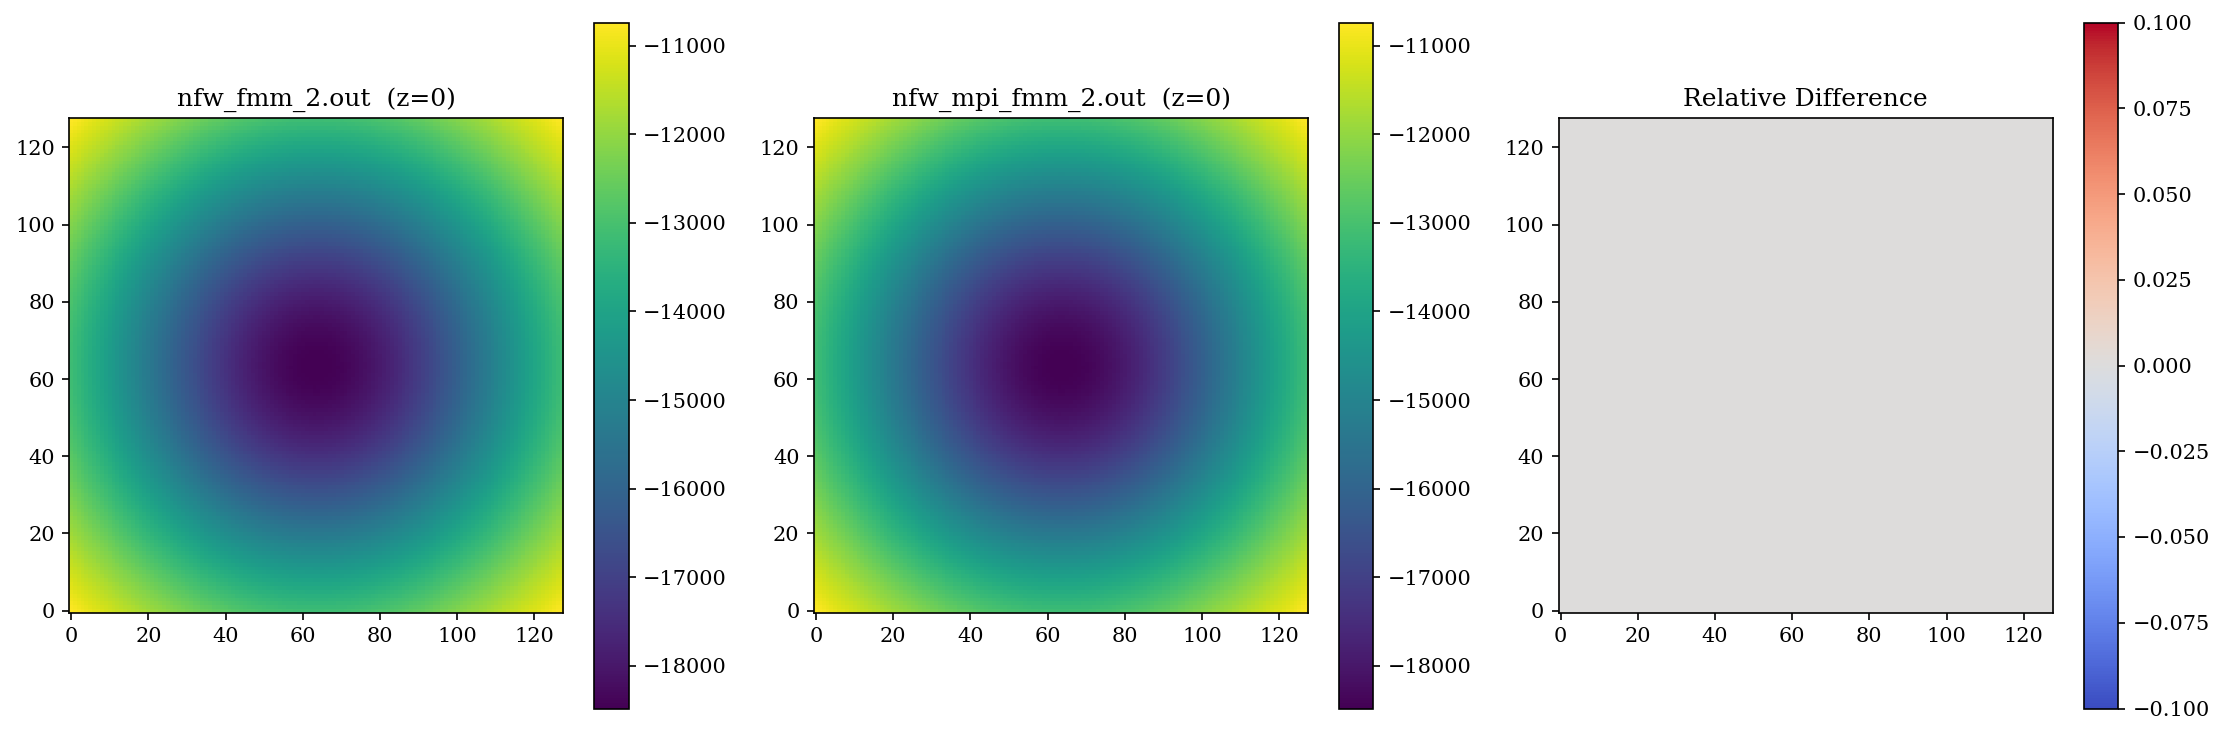

In [46]:
file1 = "nfw_fmm_2.out"
file2 = "nfw_mpi_fmm_2.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 0

df1, df2, label1, label2 = load_data(file1, file2)
plot_2d(df1, df2, label1, label2, z_slice)

In [47]:
import os
import difflib
import re

def list_files_recursively(base_dir):
    """Return all relative file paths recursively, excluding bin/ directories."""
    all_files = []
    for root, dirs, files in os.walk(base_dir):
        # skip any 'bin' subdirectory
        if "bin" in root.split(os.sep) or ".git" in root.split(os.sep) or "analyze" in root.split(os.sep) or "out" in root.split(os.sep) or "output_00001" in root.split(os.sep):
            continue
        for f in files:
            rel_path = os.path.relpath(os.path.join(root, f), base_dir)
            all_files.append(rel_path)
    return set(all_files)

folder = "amr"
dir1 = f"../"
dir2 = f"../../develop/"

files1 = list_files_recursively(dir1)
files2 = list_files_recursively(dir2)

common = files1 & files2
only_in_dir1 = files1 - files2
only_in_dir2 = files2 - files1

print(f"=== Files only in {dir1} ===")
for f in sorted(only_in_dir1):
    print("  ", f)

print(f"\n=== Files only in {dir2} ===")
for f in sorted(only_in_dir2):
    print("  ", f)

print("\n=== Differences in common files (ignoring whitespace) ===")

for f in sorted(common):
    path1 = os.path.join(dir1, f)
    path2 = os.path.join(dir2, f)
    if os.path.isfile(path1) and os.path.isfile(path2):
        with open(path1, "r", errors="ignore") as fa, open(path2, "r", errors="ignore") as fb:
            a_lines = fa.readlines()
            b_lines = fb.readlines()

        # normalize whitespace: strip + collapse internal spaces
        normalize = lambda lines: [re.sub(r"\s+", " ", line.strip()) for line in lines]
        a_norm = normalize(a_lines)
        b_norm = normalize(b_lines)

        diff = difflib.unified_diff(
            a_norm, b_norm,
            fromfile=path1, tofile=path2,
            lineterm=''
        )
        diff_list = list(diff)
        if diff_list:
            print(f"\n--- {f} ---")
            # Uncomment below if you want the diff content printed
            # for line in diff_list:
            #     print(line)


=== Files only in ../ ===
   poisson/fmm/cleanup_fmm_module.mod
   poisson/fmm/fmm_cleanup.f90
   poisson/fmm/fmm_fine_commons.f90
   poisson/fmm/fmm_fine_commons.mod
   poisson/fmm/fmm_init.f90
   poisson/fmm/fmm_multipoles.f90
   poisson/fmm/fmm_multipoles.mod
   poisson/fmm/fmm_taylor.f90
   poisson/fmm/fmm_taylor.mod
   poisson/fmm/init_fmm_module.mod
   single/ic_part
   single_offset/ic_part
   time_fmm.txt
   time_mg.txt

=== Files only in ../../develop/ ===
   nfw/nfw.tar

=== Differences in common files (ignoring whitespace) ===

--- .DS_Store ---

--- .gitignore ---

--- CMakeLists.txt ---

--- amr/adaptive_loop.f90 ---

--- amr/amr_commons.f90 ---

--- amr/amr_parameters.f90 ---

--- amr/amr_step.f90 ---

--- amr/cache_commons.f90 ---

--- amr/mdl_commons.f90 ---

--- amr/nbors_utils.f90 ---

--- amr/oct_commons.f90 ---

--- amr/read_params.f90 ---

--- amr/task_manager.f90 ---

--- poisson/force_fine.f90 ---

--- run.sh ---

--- tests/.DS_Store ---

--- utils/.DS_Store ---
